# Hidden Markov Models: Forward-Backward and Viterbi

An HMM has latent states $x_t$ and observations $y_t$ with
$$
p(x_{1:T},y_{1:T}) = p(x_1)\prod_{t=2}^{T}p(x_t|x_{t-1})\prod_{t=1}^{T}p(y_t|x_t).
$$
We compute filtering probabilities and the most likely latent path.

A hidden Markov model couples latent transitions with noisy emissions. Forward messages compute filtered evidence, backward messages incorporate future observations, and their product yields smoothed marginals. Viterbi solves a different max-product problem, so comparing the decoded path with posterior probabilities exposes uncertainty that a single path hides.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/hmm-forward-backward/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/hmm-forward-backward") if Path("python/hmm-forward-backward").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Hidden Markov Models: Forward-Backward and Viterbi**, with equations and plots designed to expose both the model and the numerical behavior.


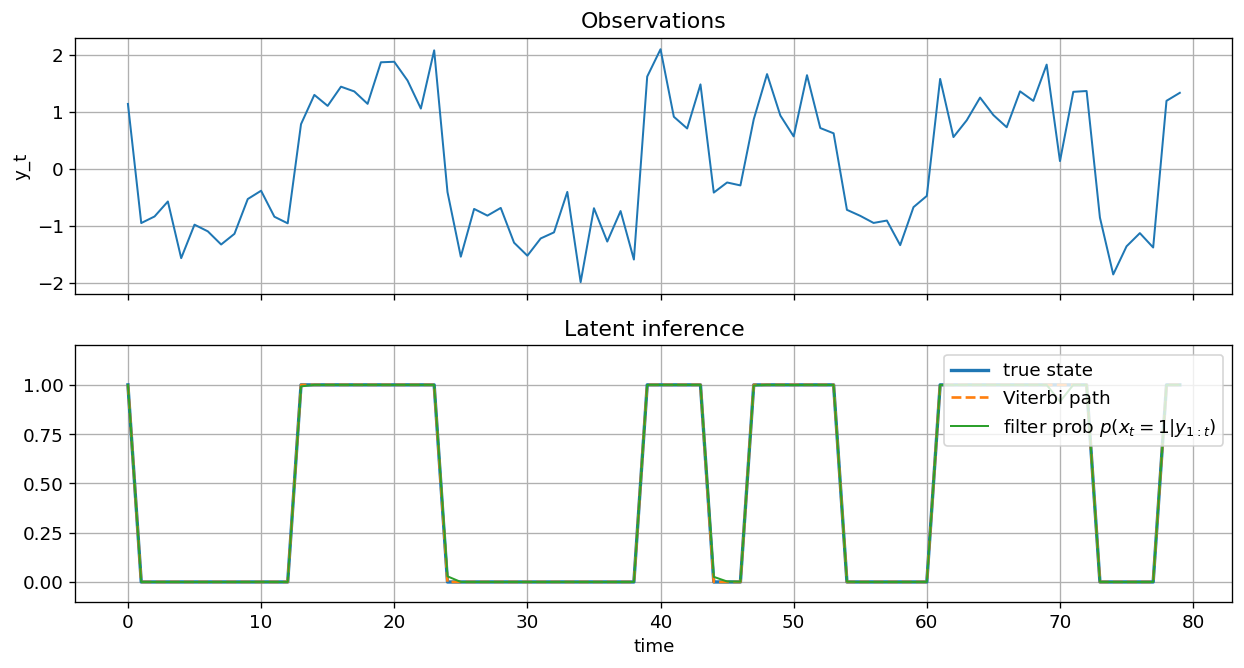

In [2]:
T = 80
A = np.array([[0.93, 0.07], [0.12, 0.88]])  # transitions
pi0 = np.array([0.5, 0.5])
means = np.array([-1.0, 1.2])
sigmas = np.array([0.45, 0.45])

states = np.zeros(T, dtype=int)
obs = np.zeros(T)
states[0] = rng.choice(2, p=pi0)
obs[0] = rng.normal(means[states[0]], sigmas[states[0]])
for t in range(1, T):
    states[t] = rng.choice(2, p=A[states[t-1]])
    obs[t] = rng.normal(means[states[t]], sigmas[states[t]])

def emis_prob(y):
    vals = []
    for k in range(2):
        v = np.exp(-0.5*((y-means[k])/sigmas[k])**2)/(np.sqrt(2*np.pi)*sigmas[k])
        vals.append(v)
    return np.array(vals)

alpha = np.zeros((T, 2))
scale = np.zeros(T)
alpha[0] = pi0 * emis_prob(obs[0])
scale[0] = alpha[0].sum(); alpha[0] /= scale[0]
for t in range(1, T):
    alpha[t] = (alpha[t-1] @ A) * emis_prob(obs[t])
    scale[t] = alpha[t].sum(); alpha[t] /= scale[t]

# Viterbi
delta = np.zeros((T, 2))
psi = np.zeros((T, 2), dtype=int)
delta[0] = np.log(pi0 + 1e-16) + np.log(emis_prob(obs[0]) + 1e-16)
for t in range(1, T):
    e = np.log(emis_prob(obs[t]) + 1e-16)
    for j in range(2):
        vals = delta[t-1] + np.log(A[:, j] + 1e-16)
        psi[t, j] = np.argmax(vals)
        delta[t, j] = vals[psi[t, j]] + e[j]

path = np.zeros(T, dtype=int)
path[-1] = np.argmax(delta[-1])
for t in range(T-2, -1, -1):
    path[t] = psi[t+1, path[t+1]]

fig, axes = plt.subplots(2, 1, figsize=(10.5, 5.7), sharex=True)
axes[0].plot(obs, lw=1.2, color="tab:blue")
axes[0].set_title("Observations")
axes[0].set_ylabel("y_t")
axes[1].plot(states, lw=2, label="true state")
axes[1].plot(path, "--", lw=1.6, label="Viterbi path")
axes[1].plot(alpha[:, 1], lw=1.2, label=r"filter prob $p(x_t=1|y_{1:t})$")
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_xlabel("time")
axes[1].set_title("Latent inference")
axes[1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- L. R. Rabiner, "A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition", Proc. IEEE, 1989.
- C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006.
- Z. Ghahramani, "An Introduction to Hidden Markov Models and Bayesian Networks", 2001.
